In [9]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


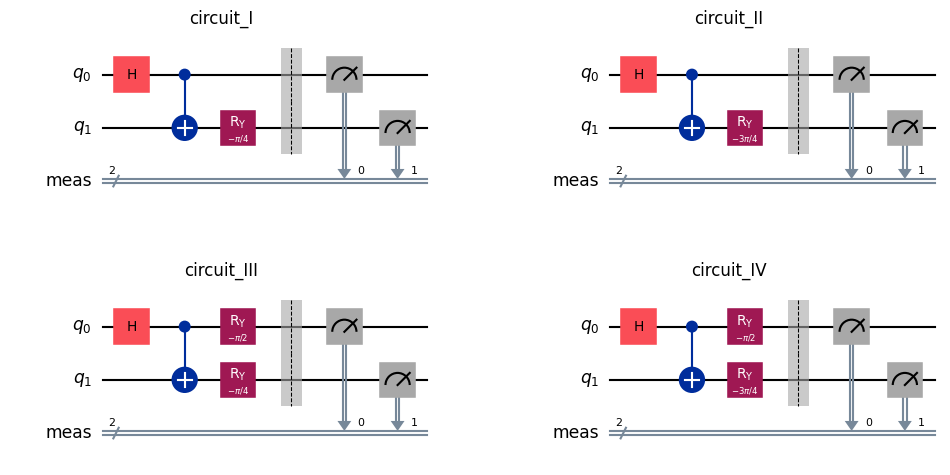

In [10]:
circuits = []

circuit = QuantumCircuit(2, name='circuit_I')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-np.pi / 4. , 1 )
circuit.measure_all()

circuits.append(circuit)

circuit = QuantumCircuit(2, name='circuit_II')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-3.*np.pi / 4. , 1 )
circuit.measure_all()

circuits.append(circuit)

circuit = QuantumCircuit(2, name='circuit_III')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-np.pi / 4. , 1 )
circuit.ry(-np.pi / 2. , 0 )
circuit.measure_all()

circuits.append(circuit)

circuit = QuantumCircuit(2, name='circuit_IV')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-3. * np.pi / 4. , 1 )
circuit.ry(-np.pi / 2. , 0 )
circuit.measure_all()

circuits.append(circuit)

fig, axs = plt.subplots(2,2, figsize=[12.,6.])
for circuit, ax in zip(circuits, axs.reshape(-1)):
    circuit.draw("mpl", ax=ax)
    ax.set_title(circuit.name)
    

In [11]:
sim = AerSimulator()

results = []
compiled_circuits = []

for idx in range(4):
    compiled_circuit = transpile(circuits[idx], sim, optimization_level=0)
    compiled_circuits.append(compiled_circuit)
    job = sim.run(compiled_circuit, shots=100) 
    result = job.result()
    results.append(result)
    
counts_list = []

for idx in range(4):
    counts = results[idx].get_counts(compiled_circuits[idx])
    counts_list.append(counts)
    print(counts)

print(counts_list)

{'01': 3, '10': 7, '00': 38, '11': 52}
{'00': 3, '10': 48, '11': 9, '01': 40}
{'01': 3, '10': 7, '00': 48, '11': 42}
{'01': 5, '11': 44, '10': 6, '00': 45}
[{'01': 3, '10': 7, '00': 38, '11': 52}, {'00': 3, '10': 48, '11': 9, '01': 40}, {'01': 3, '10': 7, '00': 48, '11': 42}, {'01': 5, '11': 44, '10': 6, '00': 45}]


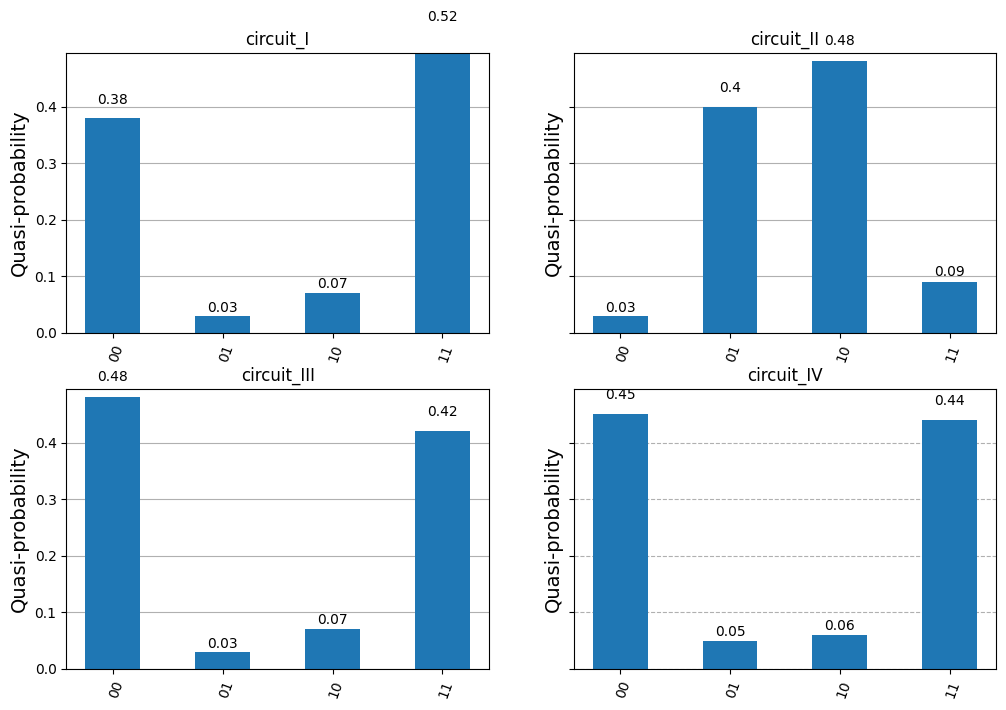

In [12]:
sfig, axs = plt.subplots(2,2,sharey=True, figsize=[12.,8.])

for counts, circuit, ax in zip(counts_list, circuits, axs.reshape(-1)):
    plot_distribution(counts, ax=ax)
    ax.set_title(circuit.name)
    ax.yaxis.grid(True)